# Estratégia de Deploy e Aprendizado Contínuo
## Desafio Data Science — Previsão de Preços de Imóveis em Seattle

Este notebook cobre:
- Diagrama completo de arquitetura de deploy em produção
- Camadas: API Gateway, Prediction Service, Model Registry, Monitoramento
- Pipeline de retraining com gatilhos automáticos
- Ciclo de aprendizado contínuo (Champion/Challenger, A/B Testing)

> **Nota:** O deploy não foi implementado — apenas documentado e diagramado conforme solicitado.


In [1]:
# =============================================================================
# DESAFIO DATA SCIENCE — Seattle House Prices
# Script 03: Diagrama de Deploy e Aprendizado Contínuo
# =============================================================================

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch
import os

try:
    OUT_DIR = os.path.join(os.path.dirname(os.path.abspath(__file__)), "..", "diagrams")
except NameError:
    OUT_DIR = os.path.join(os.getcwd(), "..", "diagrams")
os.makedirs(OUT_DIR, exist_ok=True)

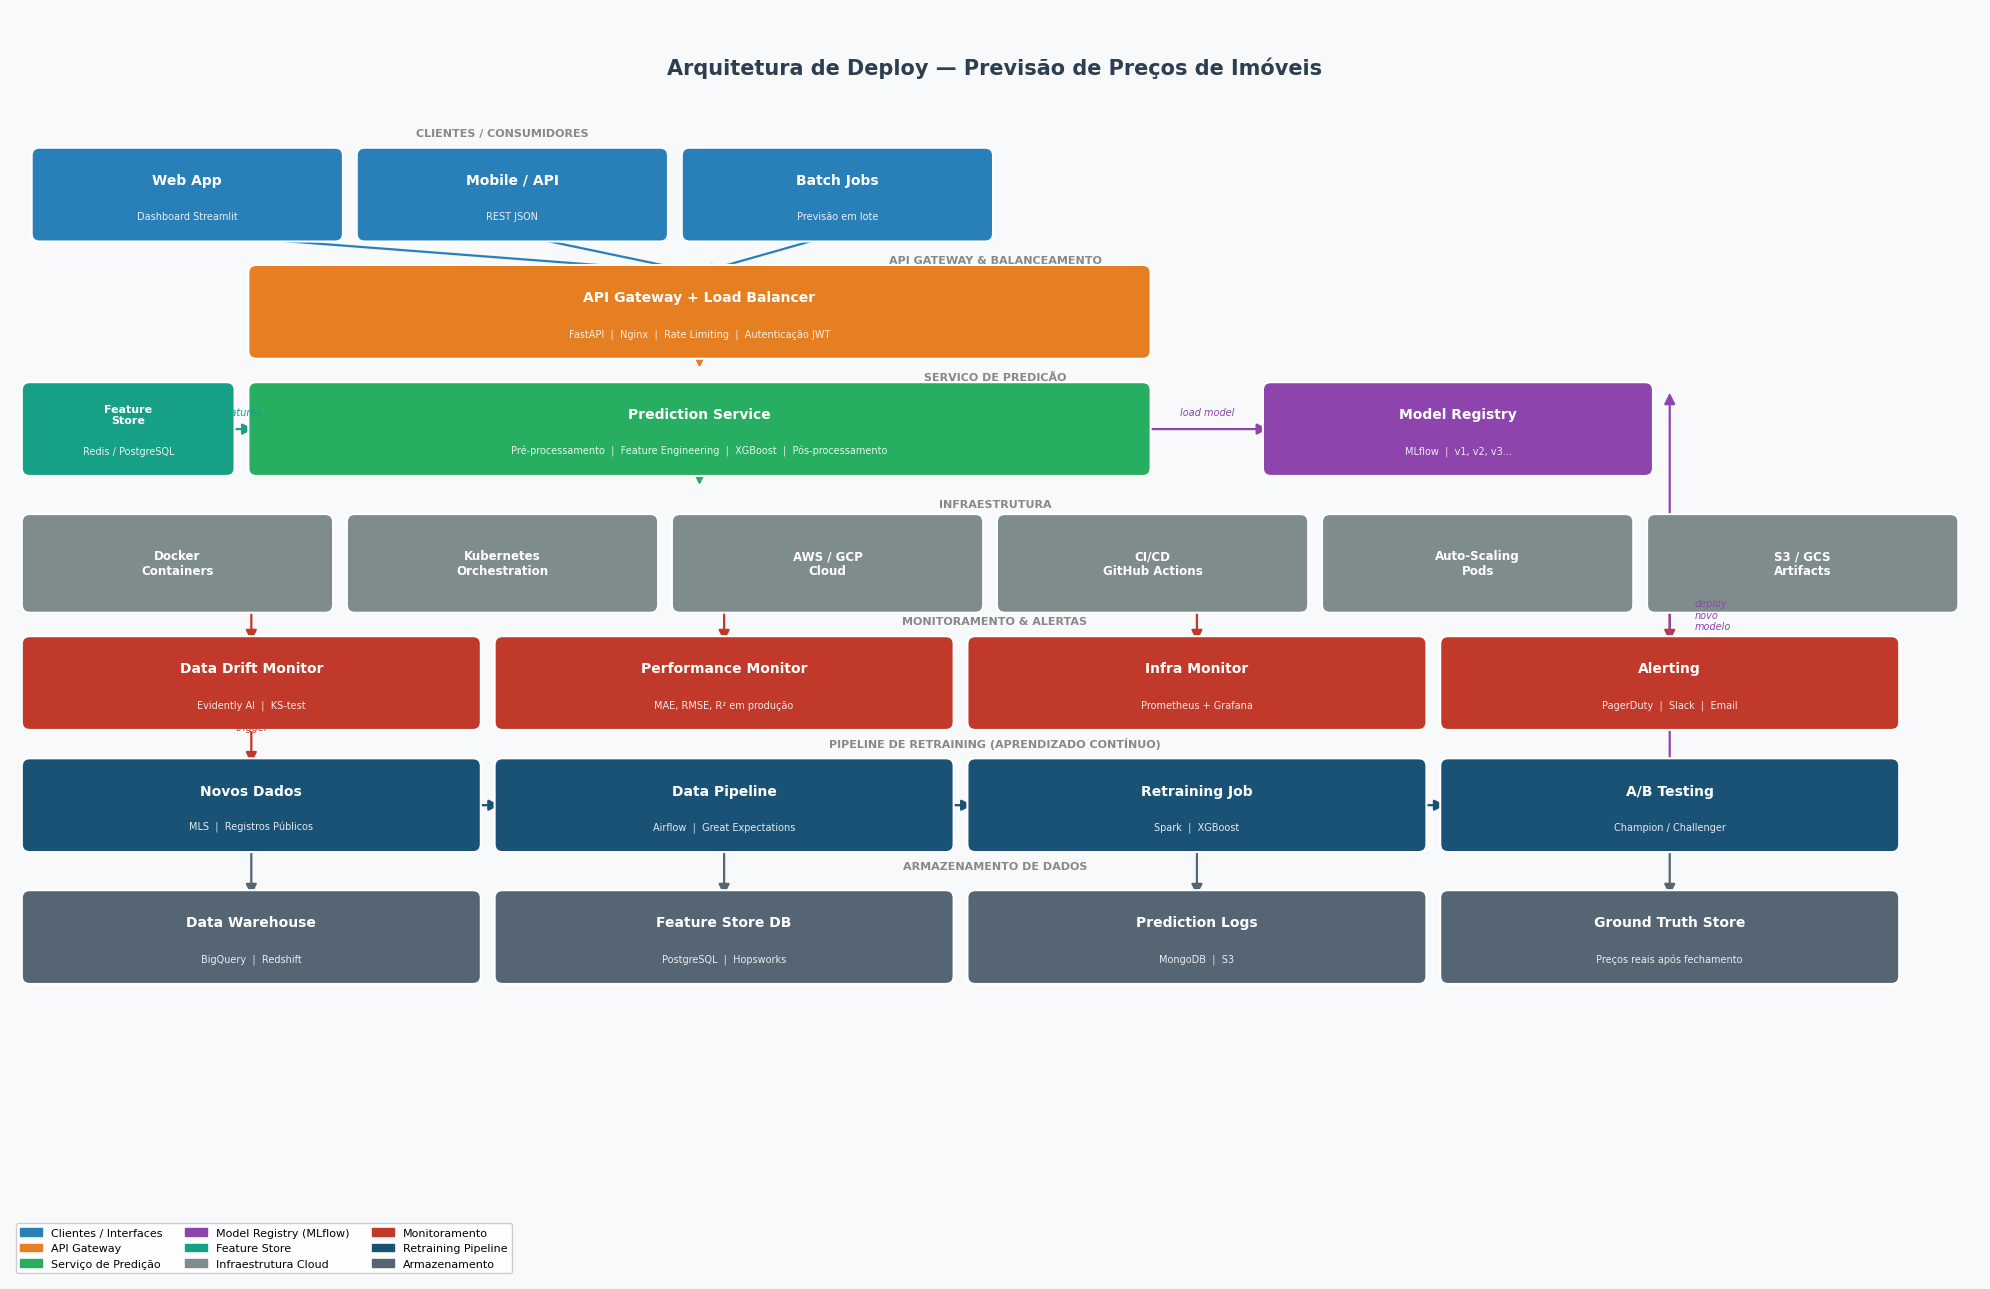

Salvo: diagrams/deploy_architecture.png


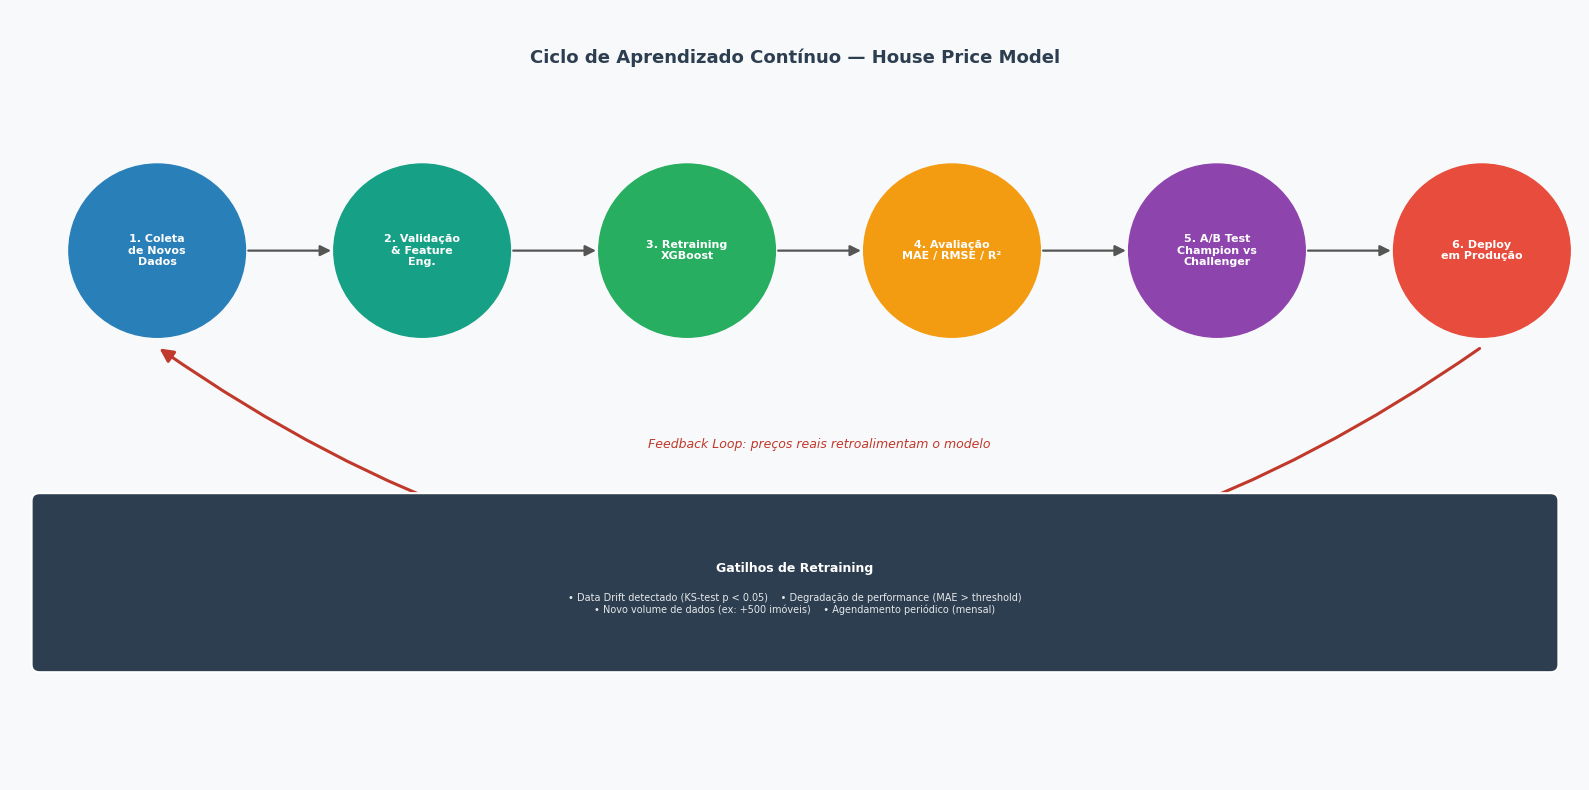

Salvo: diagrams/continuous_learning.png

=== DIAGRAMAS CONCLUIDOS ===


In [3]:
# FUNÇÕES AUXILIARES DE DESENHO 
def draw_box(ax, x, y, w, h, label, sublabel="", color="#4C72B0", fontsize=10, text_color="white"):
    rect = FancyBboxPatch((x, y), w, h,
                          boxstyle="round,pad=0.08",
                          facecolor=color, edgecolor="white", linewidth=1.5,
                          zorder=3)
    ax.add_patch(rect)
    offset_y = 0.15 if sublabel else 0
    ax.text(x + w/2, y + h/2 + offset_y,
            label, ha="center", va="center", fontsize=fontsize,
            fontweight="bold", color=text_color, zorder=4, ma="center")
    if sublabel:
        ax.text(x + w/2, y + h/2 - 0.22, sublabel,
                ha="center", va="center", fontsize=7,
                color=text_color, alpha=0.88, zorder=4, ma="center")

def draw_arrow(ax, x1, y1, x2, y2, label="", color="#555555"):
    ax.annotate("", xy=(x2, y2), xytext=(x1, y1),
                arrowprops=dict(arrowstyle="-|>", color=color,
                                lw=1.6, mutation_scale=16), zorder=2)
    if label:
        mx, my = (x1 + x2) / 2, (y1 + y2) / 2
        ax.text(mx, my + 0.12, label, ha="center", va="bottom",
                fontsize=7, color=color, style="italic")

# ===========================================================================
# DIAGRAMA 1: ARQUITETURA DE DEPLOY
# ===========================================================================
def build_deploy_diagram():
    fig, ax = plt.subplots(figsize=(20, 13))
    ax.set_xlim(0, 20)
    ax.set_ylim(0, 13)
    ax.axis("off")
    ax.set_facecolor("#F8F9FA")
    fig.patch.set_facecolor("#F8F9FA")

    # Título
    ax.text(10, 12.4, "Arquitetura de Deploy — Previsão de Preços de Imóveis",
            ha="center", va="center", fontsize=15, fontweight="bold", color="#2C3E50")

    # ---- CAMADA 1: Clientes
    ax.text(5, 11.7, "CLIENTES / CONSUMIDORES", ha="center", fontsize=8,
            color="#888888", fontweight="bold")
    draw_box(ax, 0.3, 10.7, 3.0, 0.8, "Web App", "Dashboard Streamlit", "#2980B9")
    draw_box(ax, 3.6, 10.7, 3.0, 0.8, "Mobile / API", "REST JSON", "#2980B9")
    draw_box(ax, 6.9, 10.7, 3.0, 0.8, "Batch Jobs", "Previsão em lote", "#2980B9")

    # ---- CAMADA 2: API Gateway
    ax.text(10, 10.4, "API GATEWAY & BALANCEAMENTO", ha="center", fontsize=8,
            color="#888888", fontweight="bold")
    draw_box(ax, 2.5, 9.5, 9.0, 0.8,
             "API Gateway + Load Balancer",
             "FastAPI  |  Nginx  |  Rate Limiting  |  Autenticação JWT", "#E67E22")

    for cx in [1.8, 5.1, 8.4]:
        draw_arrow(ax, cx, 10.7, 7.0, 10.3, color="#2980B9")

    draw_arrow(ax, 7.0, 9.5, 7.0, 9.3, color="#E67E22")

    # ---- CAMADA 3: Prediction Service
    ax.text(10, 9.2, "SERVIÇO DE PREDIÇÃO", ha="center", fontsize=8,
            color="#888888", fontweight="bold")
    draw_box(ax, 2.5, 8.3, 9.0, 0.8,
             "Prediction Service",
             "Pré-processamento  |  Feature Engineering  |  XGBoost  |  Pós-processamento",
             "#27AE60")

    # ---- Model Registry (lateral direito)
    draw_box(ax, 12.8, 8.3, 3.8, 0.8, "Model Registry",
             "MLflow  |  v1, v2, v3...", "#8E44AD")
    draw_arrow(ax, 11.5, 8.7, 12.8, 8.7, label="load model", color="#8E44AD")

    # ---- Feature Store (lateral esquerdo)
    draw_box(ax, 0.2, 8.3, 2.0, 0.8, "Feature\nStore",
             "Redis / PostgreSQL", "#16A085", fontsize=8)
    draw_arrow(ax, 2.2, 8.7, 2.5, 8.7, label="features", color="#16A085")

    draw_arrow(ax, 7.0, 8.3, 7.0, 8.1, color="#27AE60")

    # ---- CAMADA 4: Infraestrutura
    ax.text(10, 7.9, "INFRAESTRUTURA", ha="center", fontsize=8,
            color="#888888", fontweight="bold")
    infra = [
        (0.2,  "Docker\nContainers"),
        (3.5,  "Kubernetes\nOrchestration"),
        (6.8,  "AWS / GCP\nCloud"),
        (10.1, "CI/CD\nGitHub Actions"),
        (13.4, "Auto-Scaling\nPods"),
        (16.7, "S3 / GCS\nArtifacts"),
    ]
    for xi, lbl in infra:
        draw_box(ax, xi, 6.9, 3.0, 0.85, lbl, "", "#7F8C8D", fontsize=8.5)

    # ---- CAMADA 5: Monitoramento
    ax.text(10, 6.7, "MONITORAMENTO & ALERTAS", ha="center", fontsize=8,
            color="#888888", fontweight="bold")
    draw_box(ax, 0.2,  5.7, 4.5, 0.8, "Data Drift Monitor",
             "Evidently AI  |  KS-test", "#C0392B")
    draw_box(ax, 5.0,  5.7, 4.5, 0.8, "Performance Monitor",
             "MAE, RMSE, R² em produção", "#C0392B")
    draw_box(ax, 9.8,  5.7, 4.5, 0.8, "Infra Monitor",
             "Prometheus + Grafana", "#C0392B")
    draw_box(ax, 14.6, 5.7, 4.5, 0.8, "Alerting",
             "PagerDuty  |  Slack  |  Email", "#C0392B")

    for xi in [2.45, 7.25, 12.05, 16.85]:
        draw_arrow(ax, xi, 6.9, xi, 6.5, color="#C0392B")

    # ---- CAMADA 6: Retraining Pipeline
    ax.text(10, 5.45, "PIPELINE DE RETRAINING (APRENDIZADO CONTÍNUO)", ha="center",
            fontsize=8, color="#888888", fontweight="bold")
    draw_box(ax, 0.2,  4.45, 4.5, 0.8, "Novos Dados",
             "MLS  |  Registros Públicos", "#1A5276", text_color="white")
    draw_box(ax, 5.0,  4.45, 4.5, 0.8, "Data Pipeline",
             "Airflow  |  Great Expectations", "#1A5276", text_color="white")
    draw_box(ax, 9.8,  4.45, 4.5, 0.8, "Retraining Job",
             "Spark  |  XGBoost", "#1A5276", text_color="white")
    draw_box(ax, 14.6, 4.45, 4.5, 0.8, "A/B Testing",
             "Champion / Challenger", "#1A5276", text_color="white")

    draw_arrow(ax, 4.7,  4.85, 5.0,  4.85, color="#1A5276")
    draw_arrow(ax, 9.5,  4.85, 9.8,  4.85, color="#1A5276")
    draw_arrow(ax, 14.3, 4.85, 14.6, 4.85, color="#1A5276")

    # Seta: monitoramento dispara retraining
    draw_arrow(ax, 2.45, 5.7, 2.45, 5.25, label="trigger", color="#C0392B")

    # Seta: A/B test -> model registry (deploy novo modelo)
    draw_arrow(ax, 16.85, 4.45, 16.85, 9.1, color="#8E44AD")
    ax.text(17.1, 6.8, "deploy\nnovo\nmodelo", ha="left", va="center",
            fontsize=7, color="#8E44AD", style="italic")

    # ---- CAMADA 7: Data Storage
    ax.text(10, 4.2, "ARMAZENAMENTO DE DADOS", ha="center", fontsize=8,
            color="#888888", fontweight="bold")
    draw_box(ax, 0.2,  3.1, 4.5, 0.8, "Data Warehouse",
             "BigQuery  |  Redshift", "#566573")
    draw_box(ax, 5.0,  3.1, 4.5, 0.8, "Feature Store DB",
             "PostgreSQL  |  Hopsworks", "#566573")
    draw_box(ax, 9.8,  3.1, 4.5, 0.8, "Prediction Logs",
             "MongoDB  |  S3", "#566573")
    draw_box(ax, 14.6, 3.1, 4.5, 0.8, "Ground Truth Store",
             "Preços reais após fechamento", "#566573")

    for xi in [2.45, 7.25, 12.05, 16.85]:
        draw_arrow(ax, xi, 4.45, xi, 3.9, color="#566573")

    # ---- LEGENDA
    legend_items = [
        mpatches.Patch(color="#2980B9", label="Clientes / Interfaces"),
        mpatches.Patch(color="#E67E22", label="API Gateway"),
        mpatches.Patch(color="#27AE60", label="Serviço de Predição"),
        mpatches.Patch(color="#8E44AD", label="Model Registry (MLflow)"),
        mpatches.Patch(color="#16A085", label="Feature Store"),
        mpatches.Patch(color="#7F8C8D", label="Infraestrutura Cloud"),
        mpatches.Patch(color="#C0392B", label="Monitoramento"),
        mpatches.Patch(color="#1A5276", label="Retraining Pipeline"),
        mpatches.Patch(color="#566573", label="Armazenamento"),
    ]
    ax.legend(handles=legend_items, loc="lower left", bbox_to_anchor=(0, 0),
              ncol=3, fontsize=8, framealpha=0.95, edgecolor="#CCCCCC")

    plt.tight_layout()
    plt.savefig(os.path.join(OUT_DIR, "deploy_architecture.png"), dpi=150, bbox_inches="tight")
    plt.show()
    plt.close()
    print("Salvo: diagrams/deploy_architecture.png")

build_deploy_diagram()

# ===========================================================================
# DIAGRAMA 2: CICLO DE APRENDIZADO CONTÍNUO
# ===========================================================================
def build_continuous_learning_diagram():
    fig, ax = plt.subplots(figsize=(16, 8))
    ax.set_xlim(0, 16)
    ax.set_ylim(0, 8)
    ax.axis("off")
    ax.set_facecolor("#F8F9FA")
    fig.patch.set_facecolor("#F8F9FA")

    ax.text(8, 7.5, "Ciclo de Aprendizado Contínuo — House Price Model",
            ha="center", va="center", fontsize=13, fontweight="bold", color="#2C3E50")

    steps = [
        (1.5,  5.5, "1. Coleta\nde Novos\nDados",    "#2980B9"),
        (4.2,  5.5, "2. Validação\n& Feature\nEng.", "#16A085"),
        (6.9,  5.5, "3. Retraining\nXGBoost",        "#27AE60"),
        (9.6,  5.5, "4. Avaliação\nMAE / RMSE / R²", "#F39C12"),
        (12.3, 5.5, "5. A/B Test\nChampion vs\nChallenger", "#8E44AD"),
        (15.0, 5.5, "6. Deploy\nem Produção",         "#E74C3C"),
    ]

    for (x, y, label, color) in steps:
        circle = plt.Circle((x, y), 0.9, color=color, zorder=3)
        ax.add_patch(circle)
        ax.text(x, y, label, ha="center", va="center", fontsize=8,
                fontweight="bold", color="white", zorder=4, ma="center")

    for i in range(len(steps) - 1):
        x1 = steps[i][0] + 0.9
        x2 = steps[i+1][0] - 0.9
        y  = steps[i][1]
        draw_arrow(ax, x1, y, x2, y, color="#555555")

    # Seta de feedback (loop)
    ax.annotate("", xy=(1.5, 4.5), xytext=(15.0, 4.5),
                arrowprops=dict(arrowstyle="-|>", color="#C0392B",
                                lw=2.2, mutation_scale=20,
                                connectionstyle="arc3,rad=-0.35"), zorder=2)
    ax.text(8.25, 3.45, "Feedback Loop: preços reais retroalimentam o modelo",
            ha="center", fontsize=9, color="#C0392B", style="italic")

    # Caixa de gatilhos
    draw_box(ax, 0.3, 1.2, 15.4, 1.7,
             "Gatilhos de Retraining",
             "• Data Drift detectado (KS-test p < 0.05)    "
             "• Degradação de performance (MAE > threshold)\n"
             "• Novo volume de dados (ex: +500 imóveis)    "
             "• Agendamento periódico (mensal)",
             "#2C3E50", fontsize=9)

    plt.tight_layout()
    plt.savefig(os.path.join(OUT_DIR, "continuous_learning.png"), dpi=150, bbox_inches="tight")
    plt.show()
    plt.close()
    print("Salvo: diagrams/continuous_learning.png")

build_continuous_learning_diagram()

print("\n=== DIAGRAMAS CONCLUIDOS ===")